# Day 16: Feature Engineering and Selection in Machine Learning

___

### 📌 Objective
##### In this session, we will:
##### - Understand Feature Engineering & Feature Selection.
##### - Apply Feature Scaling (Standardization, Normalization).
##### - Generate Polynomial Features.
##### - Identify Important Features using Feature Importance methods.
##### - Improve the dataset quality for better Machine Learning models.
---
#### 🚀 Dataset: California Housing Dataset
##### This dataset contains information about various factors affecting housing prices.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.datasets import fetch_california_housing

In [2]:
#Load Dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [6]:
df['Price'] = data.target

In [7]:
#Exploratory Data Analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [8]:
#Missing values
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [10]:
df.dtypes

MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
Price         float64
dtype: object

In [11]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


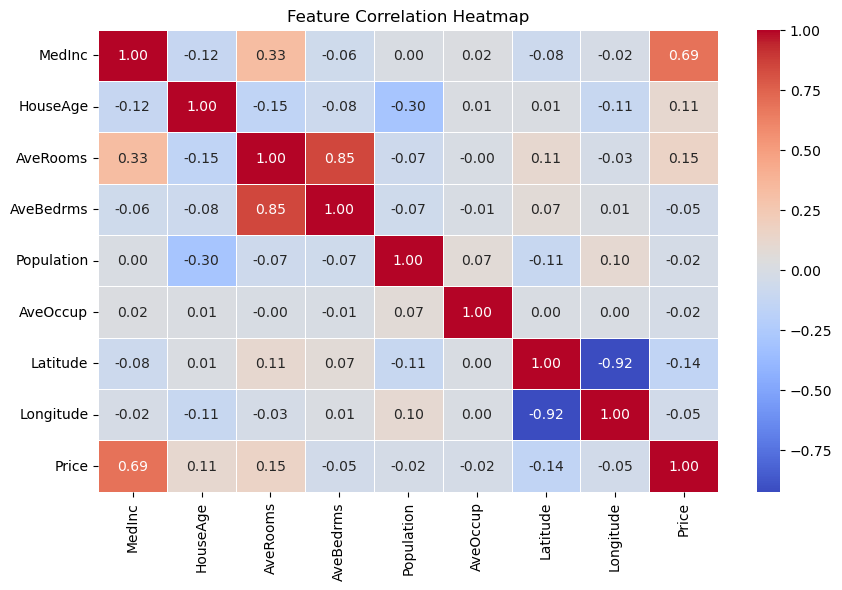

In [12]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidth=0.5)

plt.title('Feature Correlation Heatmap')
plt.show()  

In [13]:
#Feature Scaling
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df),
                         columns=df.columns)

In [14]:
#Normalization
scaler_minmax = MinMaxScaler()
df_normalized=pd.DataFrame(scaler_minmax.fit_transform(df),
                           columns=df.columns)

In [16]:
print("Scaled and Normalized Data Sample:")
print(df_scaled.head())
print(df_normalized.head())

Scaled and Normalized Data Sample:
     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  2.344766  0.982143  0.628559  -0.153758   -0.974429 -0.049597  1.052548   
1  2.332238 -0.607019  0.327041  -0.263336    0.861439 -0.092512  1.043185   
2  1.782699  1.856182  1.155620  -0.049016   -0.820777 -0.025843  1.038503   
3  0.932968  1.856182  0.156966  -0.049833   -0.766028 -0.050329  1.038503   
4 -0.012881  1.856182  0.344711  -0.032906   -0.759847 -0.085616  1.038503   

   Longitude     Price  
0  -1.327835  2.129631  
1  -1.322844  1.314156  
2  -1.332827  1.258693  
3  -1.337818  1.165100  
4  -1.337818  1.172900  
     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  0.539668  0.784314  0.043512   0.020469    0.008941  0.001499  0.567481   
1  0.538027  0.392157  0.038224   0.018929    0.067210  0.001141  0.565356   
2  0.466028  1.000000  0.052756   0.021940    0.013818  0.001698  0.564293   
3  0.354699  1.000000  0.035241   

In [17]:
#Polynomial Feature
poly = PolynomialFeatures(degree=2, include_bias=False)
df_poly=poly.fit_transform(df.drop(columns=['Price']))
print("Polynomial Feature Shape:", df_poly.shape)

Polynomial Feature Shape: (20640, 44)


In [18]:
#Feature Importance using Random Forest
X = df.drop(columns=['Price'])
y = df['Price']
model = RandomForestRegressor()
model.fit(X,y)
feature_importance = model.feature_importances_

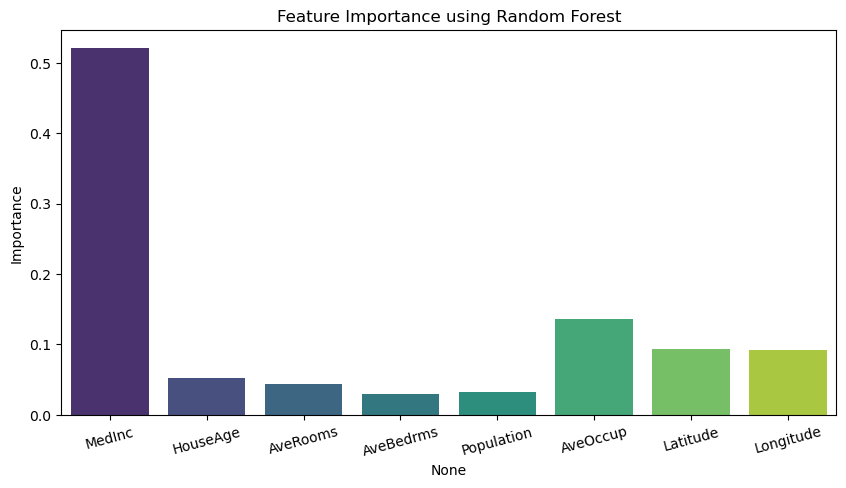

In [20]:
#Visualize Feature Importance
plt.figure(figsize=(10,5))

sns.barplot(x=X.columns,
            y=feature_importance,
            hue=X.columns,
            palette='viridis',
           legend=False)
plt.xticks(rotation=15)
plt.title('Feature Importance using Random Forest')
plt.ylabel('Importance')
plt.show()

In [21]:
#Feature Selection using SelectKBest
selector = SelectKBest(score_func=f_regression,
                       k=5)
X_selected = selector.fit_transform(X,y)
selected_features = X.columns[selector.get_support()]

print('Top Selected Features:', selected_features)

Top Selected Features: Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude'], dtype='object')
